Setup a Redis vector store that works with LlamaIndex for the FAQ, amenities, and services info.

I provide metadata information because it's useful to the user and LlamaIndex can have the LLM filter by it.

Load environment variables from .env file

In [67]:
# ruff: noqa: ERA001, D101, D103, T201, S301

import os

from dotenv import load_dotenv

load_dotenv()

True

For info on what's happening in the background

In [68]:
import logging
import sys

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
logging.getLogger().addHandler(logging.StreamHandler(stream=sys.stdout))

The default number of items to return to the LLM

In [69]:
top_k = 4

Setup the embedding model

Use HuggingFaceEmbedding running locally because OpenAIEmbedding takes a long time to initialize.

In [70]:
from llama_index.core import Settings

# from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.embeddings.openai import OpenAIEmbedding
# from llama_index.embeddings.google_genai import GoogleGenAIEmbedding

In [71]:
Settings.embed_model = OpenAIEmbedding(model="text-embedding-3-small")
# Settings.embed_model = OpenAIEmbedding()
# Settings.embed_model = HuggingFaceEmbedding("BAAI/bge-small-en-v1.5")
# Settings.embed_model = GoogleGenAIEmbedding("gemini-embedding-001", dimensions=768)

### Typing for Retrievers

Defines the data type that the retrievers return

In [72]:
from typing import Any

from pydantic import BaseModel, Field


class RetrievalItem(BaseModel):
    source: str = Field(
        ..., description="Source retriever: FAQ, amenities, or services",
    )
    metadata: dict[str, Any] = Field(
        ..., description="The metadata associated with the text.",
    )
    text: str = Field(..., description="The item name and description")
    score: float = Field(..., description="Similarity score; higher is more relevant")

### FAQ

Connect to Redis Cloud

In [73]:
from llama_index.core import StorageContext, VectorStoreIndex
from llama_index.vector_stores.redis import RedisVectorStore
from redis import Redis
from redisvl.schema import IndexSchema

redis_conn_string = os.getenv("REDIS_URL")
faq_schema = IndexSchema.from_dict(
    {
        "index": {"name": "faq", "prefix": "faq"},
        # customize fields that are indexed
        "fields": [
            # required fields for llamaindex
            {"type": "tag", "name": "id"},
            {"type": "tag", "name": "doc_id"},
            {"type": "text", "name": "text"},
            # custom for metadata filtering
            {"type": "tag", "name": "category"},
            # custom vector field for text-embedding-3-small
            {
                "type": "vector",
                "name": "vector",
                "attrs": {
                    "dims": 1536,
                    "algorithm": "hnsw",
                    "distance_metric": "cosine",
                },
            },
        ],
    },
)
redis_client = Redis.from_url(redis_conn_string, decode_responses=True) # pyright: ignore[reportArgumentType]
faq_vector_store = RedisVectorStore(
    schema=faq_schema, redis_client=redis_client, overwrite=True,
)
faq_storage_context = StorageContext.from_defaults(vector_store=faq_vector_store)

17:15:21 redisvl.index.index INFO   Index already exists, overwriting.
17:15:21 redisvl.index.index INFO   Index already exists, overwriting.
Index already exists, overwriting.


Load the FAQ

In [74]:
import pandas as pd

df_faq = pd.read_pickle("../data/pandas/faq_knowledge_base.pkl")
df_faq

,category,subcategory,question,answer,keywords,last_updated,helpful_votes,views
faq_id,,,,,,,,
FAQ000001,booking,reservations,How do I make a reservation?,You can make a reservation through our website...,"book, reserve, reservation, booking",2024-03-09,957,3813
FAQ000002,booking,check-in/out,What is the check-in/check-out time?,Check-in time is 3:00 PM and check-out time is...,"check in, check out, arrival, departure",2024-10-15,967,2793
FAQ000003,booking,modifications,Can I modify my booking?,"Yes, you can modify your booking through our w...","change, modify, update, edit",2024-12-05,443,1929
FAQ000004,booking,cancellations,What is the cancellation policy?,Free cancellation is available up to 48 hours ...,"cancel, refund, cancellation",2024-05-20,611,1300
FAQ000005,booking,special requests,Do you offer early check-in/late check-out?,"Subject to availability, early check-in and la...","early check-in, late check-out, extended stay",2024-12-18,239,3954
FAQ000006,amenities,facilities,What amenities are included?,"Our hotel offers complimentary Wi-Fi, fitness ...","amenities, facilities, services",2024-10-24,855,1860
FAQ000007,amenities,dining,Is breakfast included?,"Yes, breakfast is included with most room rate...","breakfast, dining, restaurant",2024-01-10,365,1943
FAQ000008,amenities,wellness,Do you have a fitness center?,"Yes, our fitness center is open 24/7 and featu...","fitness, gym, exercise",2024-10-05,988,1471
FAQ000009,amenities,business,Is there a swimming pool?,"Yes, we have both indoor and outdoor pools ope...","pool, swimming, recreation",2024-10-15,400,2881


Prepare data for storage by putting it into a TextNode format usable by LlamaIndex.

In [75]:
from llama_index.core.schema import TextNode


def get_faq_nodes() -> list:
    nodes = []
    for id_, row in df_faq.iterrows():
        main_text = "Question:\n" + row["question"] + "\n\nAnswer:\n" + row["answer"]
        metadata = {
            "category": row["category"],
            "subcategory": row["subcategory"],
            "keywords": row["keywords"],
            "last_updated": row["last_updated"],
        }
        node = TextNode(text=main_text, id_=id_, metadata=metadata)
        nodes.append(node)
    return nodes


faq_nodes = get_faq_nodes()

Store in vector store

In [76]:
faq_index = VectorStoreIndex(nodes=faq_nodes, storage_context=faq_storage_context)

17:15:23 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:23 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:23 llama_index.vector_stores.redis.base INFO   Added 20 documents to index faq
17:15:23 llama_index.vector_stores.redis.base INFO   Added 20 documents to index faq
Added 20 documents to index faq


Setup and test retrieval

In [77]:
faq_retriever = faq_index.as_retriever(similarity_top_k=top_k)

In [78]:
faq_retriever.retrieve("Is there a place to swim?")

17:15:24 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:24 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:24 llama_index.vector_stores.redis.base INFO   Querying index faq with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:15:24 llama_index.vector_stores.redis.base INFO   Querying index faq with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
Querying index faq with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:15:24 llama_index.vector_stores.redis.base INFO   Found 4 results for query with id ['faq:FAQ0

[NodeWithScore(node=TextNode(id_='FAQ000009', embedding=None, metadata={'category': 'amenities', 'subcategory': 'business', 'keywords': 'pool, swimming, recreation', 'last_updated': '2024-10-15'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='Question:\nIs there a swimming pool?\n\nAnswer:\nYes, we have both indoor and outdoor pools open from 6:00 AM to 10:00 PM.', mimetype='text/plain', start_char_idx=None, end_char_idx=None, text_template='{metadata_str}\n\n{content}'), score=0.5795838832860001),
 NodeWithScore(node=TextNode(id_='FAQ000008', embedding=None, metadata={'category': 'amenities', 'subcategory': 'wellness', 'keywords': 'fitness, gym, exercise', 'last_updated': '2024-10-05'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='Question:\nDo you have a fitness center?\n\nAnswer:

Setup and auto-retriever that filters over metadata.

Whether it works depends heavily on the model chosen. gpt-5-mini causes an error sometimes. I won't include this in the production code for the FAQ as there's little point.

In [79]:
faq_index_name = faq_vector_store.index_name
categories = redis_client.ft(faq_index_name).tagvals("category")
print(categories)

['amenities', 'booking', 'policies', 'services']


In [80]:
from llama_index.core.retrievers import VectorIndexAutoRetriever
from llama_index.core.vector_stores.types import MetadataInfo, VectorStoreInfo
from llama_index.llms.openai import OpenAI

Settings.llm = OpenAI(model="gpt-5", temperature=0.0, reasoning={"effort": "medium"})

faq_store_info = VectorStoreInfo(
    content_info="FAQs and their answers for the hotel",
    metadata_info=[
        MetadataInfo(
            name="category",
            type="tag",
            description=f"Category of the FAQ, one of {categories}",
        ),
    ],
)
faq_retriever = VectorIndexAutoRetriever(
    faq_index, vector_store_info=faq_store_info, similarity_top_k=top_k,
)

The auto-retriever works well with gpt-5, but it's slow. gpt-5.1 and gpt-5.2 often don't filter at all. They might understand that multiple categories can apply, so there's no point in picking one. In production, I just use a regular retriever with custom filters.

In [81]:
faq_retriever.retrieve("Is there a place to swim?")

17:15:33 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
17:15:33 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
17:15:33 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   Using query str: swimming pool
17:15:33 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   Using query str: swimming pool
Using query str: swimming pool
17:15:33 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   Using filters: [('category', '==', 'amenities')]
17:15:33 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   Using filters: [('category', '==', 'amenities')]
Using filters: [('category', '==', 'amenities')]
17:15:33 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   U

[NodeWithScore(node=TextNode(id_='FAQ000009', embedding=None, metadata={'category': 'amenities', 'subcategory': 'business', 'keywords': 'pool, swimming, recreation', 'last_updated': '2024-10-15'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='Question:\nIs there a swimming pool?\n\nAnswer:\nYes, we have both indoor and outdoor pools open from 6:00 AM to 10:00 PM.', mimetype='text/plain', start_char_idx=None, end_char_idx=None, text_template='{metadata_str}\n\n{content}'), score=0.583646059036),
 NodeWithScore(node=TextNode(id_='FAQ000006', embedding=None, metadata={'category': 'amenities', 'subcategory': 'facilities', 'keywords': 'amenities, facilities, services', 'last_updated': '2024-10-24'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='Question:\nWhat amenities are included?\n\nA

In [82]:
faq_retriever.retrieve("What's the policy on smoking?")

17:15:42 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
17:15:42 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
17:15:42 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   Using query str: smoking policy
17:15:42 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   Using query str: smoking policy
Using query str: smoking policy
17:15:42 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   Using filters: [('category', '==', 'policies')]
17:15:42 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   Using filters: [('category', '==', 'policies')]
Using filters: [('category', '==', 'policies')]
17:15:42 llama_index.core.indices.vector_store.retrievers.auto_retriever.auto_retriever INFO   U

[NodeWithScore(node=TextNode(id_='FAQ000017', embedding=None, metadata={'category': 'policies', 'subcategory': 'smoking policy', 'keywords': 'smoking, non-smoking, tobacco', 'last_updated': '2024-01-31'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='Question:\nDo you have smoking rooms?\n\nAnswer:\nAll our rooms are non-smoking. Smoking is only permitted in designated outdoor areas.', mimetype='text/plain', start_char_idx=None, end_char_idx=None, text_template='{metadata_str}\n\n{content}'), score=0.608241915703),
 NodeWithScore(node=TextNode(id_='FAQ000016', embedding=None, metadata={'category': 'policies', 'subcategory': 'pet policy', 'keywords': 'pets, animals, dogs, cats', 'last_updated': '2024-07-17'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='Question:\nWhat is your pet po

### Amenities

Connect to Redis Cloud

In [83]:
from llama_index.core import StorageContext, VectorStoreIndex
from llama_index.vector_stores.redis import RedisVectorStore
from redis import Redis
from redisvl.schema import IndexSchema

redis_conn_string = os.getenv("REDIS_URL")
amenities_schema = IndexSchema.from_dict(
    {
        "index": {"name": "amenities", "prefix": "amenities"},
        # customize fields that are indexed
        "fields": [
            # required fields for llamaindex
            {"type": "tag", "name": "id"},
            {"type": "tag", "name": "doc_id"},
            {"type": "text", "name": "text"},
            # custom fields for filtering
            {"type": "tag", "name": "category"},
            {"type": "numeric", "name": "price"},
            {"type": "numeric", "name": "duration"},
            {"type": "numeric", "name": "min_notice_hours"},
            {"type": "tag", "name": "booking_required"},
            # custom vector field for text-embedding-3-small embeddings
            {
                "type": "vector",
                "name": "vector",
                "attrs": {
                    "dims": 1536,
                    "algorithm": "hnsw",
                    "distance_metric": "cosine",
                },
            },
        ],
    },
)
redis_client = Redis.from_url(redis_conn_string, decode_responses=True) # pyright: ignore[reportArgumentType]
amenities_vector_store = RedisVectorStore(
    schema=amenities_schema, redis_client=redis_client, overwrite=True,
)
amenities_storage_context = StorageContext.from_defaults(
    vector_store=amenities_vector_store,
)

17:15:43 redisvl.index.index INFO   Index already exists, overwriting.
17:15:43 redisvl.index.index INFO   Index already exists, overwriting.
Index already exists, overwriting.


Add amenity information

In [84]:
import pandas as pd

df_amenities = pd.read_pickle("../data/pandas/amenities.pkl")
df_amenities.head()

,category,name,price,duration,description,availability,booking_required,min_notice_hours
amenity_id,,,,,,,,
AM000001,Spa Services,Swedish Massage,120,60,Experience pure relaxation with our Swedish Ma...,24/7,True,2
AM000002,Spa Services,Deep Tissue Massage,140,60,"Indulge in our signature Deep Tissue Massage, ...",6:00-22:00,False,4
AM000003,Spa Services,Couples Massage Experience,280,90,Indulge in our signature Couples Massage Exper...,By appointment only,False,0
AM000004,Spa Services,Hot Stone Therapy,160,90,Experience pure relaxation with our Hot Stone ...,6:00-22:00,False,1
AM000005,Spa Services,Luxury Facial Treatment,180,90,Indulge in our signature Luxury Facial Treatme...,24/7,False,24


Prepare data for storage by putting it into LlamaIndex's TextNode format

In [85]:
def get_amenities_nodes() -> list[TextNode]:
    nodes = []
    for id_, row in df_amenities.iterrows():
        main_text = "Name:" + row["name"] + "\n\nDescription:\n" + row["description"]
        metadata = {
            "category": row["category"],
            "price": row["price"],
            "duration": row["duration"],
            "availability": row["availability"],
            "booking_required": str(row["booking_required"]),
            "min_notice_hours": row["min_notice_hours"],
        }
        node = TextNode(text=main_text, id_=id_, metadata=metadata)
        nodes.append(node)
    return nodes


amenities_nodes = get_amenities_nodes()

Store in vector store, setup retriever

In [86]:
amenities_index = VectorStoreIndex(
    nodes=amenities_nodes, storage_context=amenities_storage_context,
)
amenities_retriever = amenities_index.as_retriever(similarity_top_k=top_k)

17:15:43 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:43 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:43 llama_index.vector_stores.redis.base INFO   Added 34 documents to index amenities
17:15:43 llama_index.vector_stores.redis.base INFO   Added 34 documents to index amenities
Added 34 documents to index amenities


In [87]:
amenities_retriever.retrieve("Can I get a massage?")

17:15:43 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:43 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:43 llama_index.vector_stores.redis.base INFO   Querying index amenities with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:15:43 llama_index.vector_stores.redis.base INFO   Querying index amenities with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
Querying index amenities with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:15:44 llama_index.vector_stores.redis.base INFO   Found 4 results for query 

[NodeWithScore(node=TextNode(id_='AM000002', embedding=None, metadata={'category': 'Spa Services', 'price': 140, 'duration': 60, 'availability': '6:00-22:00', 'booking_required': 'False', 'min_notice_hours': 4}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='Name:Deep Tissue Massage\n\nDescription:\nIndulge in our signature Deep Tissue Massage, where 60 minutes of expert care will melt away stress and tension. This treatment features natural skincare products and customized therapeutic approaches to provide rejuvenated and restored.', mimetype='text/plain', start_char_idx=None, end_char_idx=None, text_template='{metadata_str}\n\n{content}'), score=0.482513129711),
 NodeWithScore(node=TextNode(id_='AM000003', embedding=None, metadata={'category': 'Spa Services', 'price': 280, 'duration': 90, 'availability': 'By appointment only', 'booking_required': 'False', 'min_notice_hours': 0}, excl

Setup and filters over metadata. I originally used the LlamaIndex auto-retriever, but that's an over-complication. The main reason to use it is for category filtering, but the category to use isn't always obvious, so I just dropped that in the end. The Redis API also doesn't properly cast datatypes, so the auto-retriever failed when used over things like the price, so I had to setup those manually anyway.

In [88]:
from llama_index.core.vector_stores.types import (
    FilterOperator,
    MetadataFilter,
    MetadataFilters,
)


def _range_filters(  # noqa: PLR0913
    *,
    booking_required: bool | None = None,
    min_price: float | None = None,
    max_price: float | None = None,
    min_notice_hours: int | None = None,
    max_notice_hours: int | None = None,
    min_duration_minutes: int | None = None,
    max_duration_minutes: int | None = None,
) -> MetadataFilters | None:
    filters: list[MetadataFilter | MetadataFilters] = []

    if booking_required is not None:
        filters.append(
            MetadataFilter(
                key="booking_required",
                operator=FilterOperator.EQ,
                value="True" if booking_required else "False",
            ),
        )

    if min_price is not None:
        filters.append(
            MetadataFilter(
                key="price", operator=FilterOperator.GTE, value=float(min_price),
            ),
        )
    if max_price is not None:
        filters.append(
            MetadataFilter(
                key="price", operator=FilterOperator.LTE, value=float(max_price),
            ),
        )

    if min_notice_hours is not None:
        filters.append(
            MetadataFilter(
                key="min_notice_hours",
                operator=FilterOperator.GTE,
                value=int(min_notice_hours),
            ),
        )
    if max_notice_hours is not None:
        filters.append(
            MetadataFilter(
                key="min_notice_hours",
                operator=FilterOperator.LTE,
                value=int(max_notice_hours),
            ),
        )

    if min_duration_minutes is not None:
        filters.append(
            MetadataFilter(
                key="duration",
                operator=FilterOperator.GTE,
                value=int(min_duration_minutes),
            ),
        )
    if max_duration_minutes is not None:
        filters.append(
            MetadataFilter(
                key="duration",
                operator=FilterOperator.LTE,
                value=int(max_duration_minutes),
            ),
        )

    return MetadataFilters(filters=filters) if filters else None


The query_amenities agent tool

In [89]:
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from llama_index.core.retrievers import VectorIndexRetriever


@tool(parse_docstring=True)
def query_amenities(  # noqa: PLR0913
    query: str,
    booking_required: bool | None = None,  # noqa: FBT001
    min_price: float | None = None,
    max_price: float | None = None,
    min_notice_hours: int | None = None,
    max_notice_hours: int | None = None,
    min_duration_minutes: int | None = None,
    max_duration_minutes: int | None = None,
) -> list[RetrievalItem]:
    """Provide information about the hotel amenities in response to a passed-in query.

    Supports optional range filtering on numeric fields.

    Args:
        query (string): The query string.
        booking_required: Restrict results to booking_required==True/False.
        min_price (float, optional): Minimum price (inclusive).
        max_price (float, optional): Maximum price (inclusive).
        min_notice_hours (int, optional): Minimum notice hours (inclusive).
        max_notice_hours (int, optional): Maximum notice hours (inclusive).
        min_duration_minutes (int, optional): Minimum duration in minutes (inclusive).
        max_duration_minutes (int, optional): Maximum duration in minutes (inclusive).

    Returns:
        list[RetrievalItem]: The retrieved results and their associated source,
        metadata, and RAG similarity score.

    """
    filters = _range_filters(
        booking_required=booking_required,
        min_price=min_price,
        max_price=max_price,
        min_notice_hours=min_notice_hours,
        max_notice_hours=max_notice_hours,
        min_duration_minutes=min_duration_minutes,
        max_duration_minutes=max_duration_minutes,
    )

    amenities_retriever = VectorIndexRetriever(
        index=amenities_index, filters=filters, similarity_top_k=top_k,
    )

    nodes = amenities_retriever.retrieve(query)

    return [
        RetrievalItem(
            source="amenities",
            metadata=dict(getattr(n, "metadata", {})),
            text=getattr(n, "text", ""),
            score=getattr(n, "score", 0),
        )
        for n in nodes
    ]

Setup an agent to test the query_amenities tool

In [90]:
from langchain.agents import create_agent

SYSTEM_PROMPT = \
"""You are a hotel information assistant. You must answer user questions only using
information returned by the hotel amenities search tool.

**Core rules**
* Always use the tool to look up amenities relevant to the user's request before
    answering.
* Do not invent, guess, or infer details that are not explicitly present in tool
    results.
* If the user asks for something not found, say you couldn't find it and offer the
    closest relevant matches (if any).
* Your results are not exhaustive; do not claim completeness.
* Assume all prices are in USD unless the tool indicates otherwise.
* Do not mention "database," "RAG," "embeddings," or internal implementation. You may
    say you "looked it up" or "searched."

**Retrieval behavior**
* Convert the user's request into a search intent (categories, keywords, constraints
    like price/duration/availability).
* Prefer precision: return only amenities that clearly match the request.
* If the request is broad ("spa options"), return a small curated set (e.g., 3-8) that
    best represent the category.
* If the request is narrow and no exact hit exists, return near matches and explain why
    they're the closest.

**Response requirements**
You may provide a once sentence introduction to the results. List the relevant amenities
    afterwards.
For each amenity you include, present **only** the fields you have from the tool, using
    this schema and order:

**Name:**
**Category:**
**Price (USD):**
**Duration (minutes):**
**Availability:**
**Booking required:**
**Minimum notice (hours):**
**Description:**

* If a field is missing from the tool output, write "Not specified."
* Do not add advice, policies, instructions, or booking steps unless the tool output
    explicitly contains them.
* Do not offer to perform actions (booking, calling, emailing, etc.).

**After answering**
End with exactly one question:
"Is there any other information I can provide about the hotel?"
"""

gpt_version = "gpt-5.2"
amenities_llm = ChatOpenAI(
    model=gpt_version, temperature=0, reasoning={"effort": "medium"},
)
amenities_agent = create_agent(
    model=amenities_llm, tools=[query_amenities], system_prompt=SYSTEM_PROMPT,
)

A helper function to get the text of the output from the agent

In [91]:
def get_output_text(query_result: dict[str, Any]) -> str:
    last_result = query_result["messages"][-1]
    for c in last_result.content:
        if "text" in c:
            return c["text"]
    return ""

A few tests

gpt-5.1 keeps listing the Private Pilates Session in this test. gpt-5.2 almost never does.

In [92]:
result = amenities_agent.invoke(
    {"messages": [{"role": "user", "content": "I would like an hour long massage"}]},
)
print(get_output_text(result))

17:15:45 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:15:45 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:15:46 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:46 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:46 llama_index.vector_stores.redis.base INFO   Querying index amenities with query (@duration:[60 +inf] @duration:[-inf 60])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:15:46 llama_index.vector_stores.redis.base INFO   Querying index amenities with query (@duration:[60 +inf] @duration:[-inf 60])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id t

In [93]:
result = amenities_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "What can my kids do for a couple of hours?"},
        ],
    },
)
print(get_output_text(result))

17:15:53 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:15:53 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:15:54 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:54 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:15:54 llama_index.vector_stores.redis.base INFO   Querying index amenities with query (@duration:[90 +inf] @duration:[-inf 180])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:15:54 llama_index.vector_stores.redis.base INFO   Querying index amenities with query (@duration:[90 +inf] @duration:[-inf 180])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id

In [94]:
result = amenities_agent.invoke(
    {"messages": [{"role": "user", "content": "What can I do at the pool?"}]},
)
print(get_output_text(result))

17:16:12 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:12 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:13 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:13 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:13 llama_index.vector_stores.redis.base INFO   Querying index amenities with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:16:13 llama_index.vector_stores.redis.base INFO   Querying index amenities with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4

In [95]:
result = amenities_agent.invoke(
    {"messages": [{"role": "user", "content": "What can I do without a booking?"}]},
)
print(get_output_text(result))

17:16:22 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:22 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:22 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:22 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:22 llama_index.vector_stores.redis.base INFO   Querying index amenities with query @booking_required:{False}=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:16:22 llama_index.vector_stores.redis.base INFO   Querying index amenities with query @booking_required:{False}=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distanc

Test for hallucination on something that obviously won't retrieve relevant information

In [96]:
result = amenities_agent.invoke(
    {"messages": [{"role": "user", "content": "What can I see at your petting zoo?"}]},
)
print(get_output_text(result))

17:16:29 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:29 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:30 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:30 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:30 llama_index.vector_stores.redis.base INFO   Querying index amenities with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:16:30 llama_index.vector_stores.redis.base INFO   Querying index amenities with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4

### Services

I would like to combine this with amenities as the dataset columns are almost identical, but this set doesn't have availability information. In practice, I would just ask for this information, but I can't do that here, so I'm keeping them separate.

Connect to Redis Cloud

In [97]:
from llama_index.core import StorageContext, VectorStoreIndex
from llama_index.vector_stores.redis import RedisVectorStore
from redisvl.schema import IndexSchema

redis_conn_string = os.getenv("REDIS_URL")
services_schema = IndexSchema.from_dict(
    {
        "index": {"name": "services", "prefix": "services"},
        # customize fields that are indexed
        "fields": [
            # required fields for llamaindex
            {"type": "tag", "name": "id"},
            {"type": "tag", "name": "doc_id"},
            {"type": "text", "name": "text"},
            # custom fields for filtering
            {"type": "tag", "name": "service_type"},
            {"type": "numeric", "name": "price"},
            {"type": "numeric", "name": "duration"},
            {"type": "numeric", "name": "min_notice_hours"},
            {"type": "tag", "name": "department"},
            {"type": "tag", "name": "booking_required"},
            # custom vector field for text-embedding-3-small embeddings
            {
                "type": "vector",
                "name": "vector",
                "attrs": {
                    "dims": 1536,
                    "algorithm": "hnsw",
                    "distance_metric": "cosine",
                },
            },
        ],
    },
)
redis_client = Redis.from_url(redis_conn_string, decode_responses=True) # pyright: ignore[reportArgumentType]
services_vector_store = RedisVectorStore(
    schema=services_schema, redis_client=redis_client, overwrite=True,
)
services_storage_context = StorageContext.from_defaults(
    vector_store=services_vector_store,
)

17:16:36 redisvl.index.index INFO   Index already exists, overwriting.
17:16:36 redisvl.index.index INFO   Index already exists, overwriting.
Index already exists, overwriting.


Add services information

In [98]:
df_services = pd.read_pickle("../data/pandas/services.pkl")
df_services

,service_type,name,description,duration_minutes,price,department,booking_required,min_notice_hours
service_id,,,,,,,,
SV000001,Spa Treatment,Spa Treatment - 120 min,Swedish massage for 120 minutes using Modern t...,120,264.98,Spa & Wellness,True,4
SV000002,Spa Treatment,Spa Treatment - 60 min,Luxurious 60-minute Deep Tissue treatment feat...,60,232.03,Spa & Wellness,True,4
SV000003,Spa Treatment,Spa Treatment - 120 min,Premium Deep Tissue experience for 120 minutes...,120,251.99,Spa & Wellness,True,24
SV000004,Spa Treatment,Spa Treatment - 90 min,Luxurious 90-minute Hot Stone treatment featur...,90,157.55,Spa & Wellness,True,1
SV000005,Personal Training,Personal Training - 60 min,Custom 60-minute HIIT workout emphasizing Core...,60,133.13,Fitness Center,True,4
SV000006,Personal Training,Personal Training - 30 min,Personalized HIIT training for 30 minutes targ...,30,138.75,Fitness Center,True,4
SV000007,Personal Training,Personal Training - 60 min,Personalized Functional Fitness training for 6...,60,82.20,Fitness Center,True,24
SV000008,Personal Training,Personal Training - 60 min,Custom 60-minute Strength Training workout emp...,60,143.70,Fitness Center,True,2
SV000009,Wellness Consultation,Wellness Consultation - 60 min,In-depth Wellness Strategy session for 60 minu...,60,94.86,Spa & Wellness,True,1


Prepare data for storage by putting it into LlamaIndex's TextNode format

In [99]:
def get_services_nodes() -> list[TextNode]:
    nodes = []
    for id_, row in df_services.iterrows():
        main_text = "Name:" + row["name"] + "\n\nDescription:\n" + row["description"]
        metadata = {
            "service_type": row["service_type"],
            "duration": row["duration_minutes"],
            "price": row["price"],
            "department": row["department"],
            "booking_required": str(row["booking_required"]),
            "min_notice_hours": row["min_notice_hours"],
        }
        node = TextNode(text=main_text, id_=id_, metadata=metadata)
        nodes.append(node)
    return nodes


services_nodes = get_services_nodes()

Setup the vector store and retriever

In [100]:
services_index = VectorStoreIndex(
    nodes=services_nodes, storage_context=services_storage_context,
)
services_retriever = services_index.as_retriever(similarity_top_k=top_k)

17:16:37 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:37 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:37 llama_index.vector_stores.redis.base INFO   Added 25 documents to index services
17:16:37 llama_index.vector_stores.redis.base INFO   Added 25 documents to index services
Added 25 documents to index services


In [101]:
services_retriever.retrieve("I want to do some pilates.")

17:16:37 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:37 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:37 llama_index.vector_stores.redis.base INFO   Querying index services with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:16:37 llama_index.vector_stores.redis.base INFO   Querying index services with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
Querying index services with query *=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:16:37 llama_index.vector_stores.redis.base INFO   Found 4 results for query wit

[NodeWithScore(node=TextNode(id_='SV000024', embedding=None, metadata={'service_type': 'Group Fitness Class', 'duration': 45, 'price': 30.93, 'department': 'Fitness Center', 'booking_required': 'True', 'min_notice_hours': 1}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='Name:Group Fitness Class - 45 min\n\nDescription:\nEngaging 45-minute Pilates class emphasizing Strength. Group Motivation.', mimetype='text/plain', start_char_idx=None, end_char_idx=None, text_template='{metadata_str}\n\n{content}'), score=0.49174410104800004),
 NodeWithScore(node=TextNode(id_='SV000025', embedding=None, metadata={'service_type': 'Group Fitness Class', 'duration': 45, 'price': 40.18, 'department': 'Fitness Center', 'booking_required': 'True', 'min_notice_hours': 2}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator

Setup the query_services tool. Uses the _range_filters from above.

In [102]:
from langchain.tools import tool


@tool(parse_docstring=True)
def query_services(  # noqa: PLR0913
    query: str,
    booking_required: bool | None = None,  # noqa: FBT001
    min_price: float | None = None,
    max_price: float | None = None,
    min_notice_hours: int | None = None,
    max_notice_hours: int | None = None,
    min_duration_minutes: int | None = None,
    max_duration_minutes: int | None = None,
) -> list[RetrievalItem]:
    """Provide information about the hotel's services in response to a passed-in query.

    Supports optional range filtering on numeric fields.

    Args:
        query (string): The query string.
        booking_required: Restrict results to booking_required==True/False.
        min_price (float, optional): Minimum price (inclusive).
        max_price (float, optional): Maximum price (inclusive).
        min_notice_hours (int, optional): Minimum notice hours (inclusive).
        max_notice_hours (int, optional): Maximum notice hours (inclusive).
        min_duration_minutes (int, optional): Minimum duration in minutes (inclusive).
        max_duration_minutes (int, optional): Maximum duration in minutes (inclusive).

    Returns:
        list[RetrievalItem]: The retrieved results and their associated source,
        metadata, and RAG similarity score.

    """
    filters = _range_filters(
        booking_required=booking_required,
        min_price=min_price,
        max_price=max_price,
        min_notice_hours=min_notice_hours,
        max_notice_hours=max_notice_hours,
        min_duration_minutes=min_duration_minutes,
        max_duration_minutes=max_duration_minutes,
    )

    retriever = VectorIndexRetriever(
        index=services_index, filters=filters, similarity_top_k=top_k,
    )

    nodes = retriever.retrieve(query)

    return [
        RetrievalItem(
            source="services",
            metadata=dict(getattr(n, "metadata", {})),
            text=getattr(n, "text", ""),
            score=getattr(n, "score", 0),
        )
        for n in nodes
    ]

Test the query_services tool as part of an agent.

In [103]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

SYSTEM_PROMPT = \
"""You are a hotel information assistant. You must answer user questions only using
information returned by the hotel services search tool.

**Core rules**
* Always use the tool to look up amenities relevant to the user's request before
    answering.
* Do not invent, guess, or infer details that are not explicitly present in tool
    results.
* If the user asks for something not found, say you couldn't find it and offer the
    closest relevant matches (if any).
* Your results are not exhaustive; do not claim completeness.
* Assume all prices are in USD unless the tool indicates otherwise.
* Do not mention "database," "RAG," "embeddings," or internal implementation. You ma
    say you "looked it up" or "searched."

**Retrieval behavior**
* Convert the user's request into a search intent (service types, keywords, constraints
    like price/duration/availability).
* Prefer precision: return only services that clearly match the request.
* If the request is broad ("spa options"), return a small curated set (e.g., 3-8) that
    best represent the service type.
* If the request is narrow and no exact hit exists, return near matches and explain why
    they're the closest.

**Response requirements**
You may provide a once sentence introduction to the results. List the relevant services
    afterwards.
For each service you include, present **only** the fields you have from the tool, using
    this schema and order:

**Name:**
**Service type:**
**Department:**
**Price (USD):**
**Duration (minutes):**
**Booking required:**
**Minimum notice (hours):**
**Description:**

* If a field is missing from the tool output, write "Not specified."
* Do not add advice, policies, instructions, or booking steps unless the tool output
    explicitly contains them.
* Do not offer to perform actions (booking, calling, emailing, etc.).

**After answering**
End with exactly one question:
"Is there any other information I can provide about the hotel?"
"""

gpt_version = "gpt-5.2"
services_llm = ChatOpenAI(
    model=gpt_version, temperature=0, reasoning={"effort": "medium"},
)
services_agent = create_agent(
    model=services_llm, tools=[query_services], system_prompt=SYSTEM_PROMPT,
)

A helper function to grab the text part of the output from the agent.

In [104]:
def get_output_text(query_result: dict[str, Any]) -> str:
    last_result = query_result["messages"][-1]
    for c in last_result.content:
        if "text" in c:
            return c["text"]
    return ""

Run a couple of tests on the agent with the query_services tool

In [105]:
result = services_agent.invoke(
    {"messages": [{"role": "user", "content": "I would like an hour long massage"}]},
)
print(get_output_text(result))

17:16:39 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:39 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:39 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:39 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:39 llama_index.vector_stores.redis.base INFO   Querying index services with query (@duration:[60 +inf] @duration:[-inf 60])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:16:39 llama_index.vector_stores.redis.base INFO   Querying index services with query (@duration:[60 +inf] @duration:[-inf 60])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id tex

In [106]:
result = services_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "What can I do for between $50 and $100?"},
        ],
    },
)
print(get_output_text(result))

17:16:45 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:45 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:45 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:45 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:45 llama_index.vector_stores.redis.base INFO   Querying index services with query (@price:[50.0 +inf] @price:[-inf 100.0])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:16:45 llama_index.vector_stores.redis.base INFO   Querying index services with query (@price:[50.0 +inf] @price:[-inf 100.0])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text 

### Combine into a single agent
Old method using create_agent. I switch to using a DAG below.

For reranking. Asking the LLM to copy all the text and metadata as arguments to the reranker does not work.

In [107]:
class RetrievalItemLite(BaseModel):
    source: str = Field(..., description="FAQ | amenities | services")
    item_id: str = Field(..., description="Stable identifier for this item")
    score: float = Field(..., description="Similarity score; higher is more relevant")

Re-define (or define for the first time for FAQ) query tools to return RetrievalItemLite

In [108]:
from langchain.tools import tool


@tool(parse_docstring=True)
def query_faq(query: str) -> list[RetrievalItemLite]:
    """Retrieve FAQ entries relevant to a user query.

    This tool performs vector search over the **FAQ** knowledge base. Use it
    when the user asks about hotel policies, rules, hours, check-in/check-out,
    deposits, cancellations, parking, pet policy, accessibility, or other
    "how does the hotel work" questions.

    Notes:
        - This tool returns lightweight items (source, item_id, score). The
            system will later rerank across sources and then hydrate the final
            selection to retrieve full text + metadata.
        - If you are unsure whether a question is policy-related, it is still
            safe to call this tool; irrelevant FAQ hits will be dropped later.

    Args:
        query: Natural-language query describing what the user wants.

    Returns:
        list[RetrievalItemLite]: Up to ``top_k`` lightweight FAQ matches.

    Examples:
        - "What time is check-in?"
        - "Do you allow pets?"
        - "Is there parking and how much does it cost?"
        - "What is the cancellation policy?"

    """
    nodes = faq_retriever.retrieve(query)

    return [
        RetrievalItemLite(
            source="faq", item_id=getattr(n, "id_", ""), score=getattr(n, "score", 0),
        )
        for n in nodes
    ]

In [109]:
@tool(parse_docstring=True)
def query_amenities(  # noqa: PLR0913
    query: str,
    booking_required: bool | None = None,  # noqa: FBT001
    min_price: float | None = None,
    max_price: float | None = None,
    min_notice_hours: int | None = None,
    max_notice_hours: int | None = None,
    min_duration_minutes: int | None = None,
    max_duration_minutes: int | None = None,
) -> list[RetrievalItemLite]:
    """Retrieve hotel amenities relevant to a user query.

    This tool performs vector search over the **amenities** catalog and can
    apply optional metadata constraints. All provided constraints are combined
    using logical **AND**.

    Use this tool when the user asks about amenities such as facilities,
    on-property features, classes, rentals, or other amenity offerings.

    Args:
        query: Natural-language query describing what the user wants.
        booking_required: Restrict results to booking_required==True/False.
        min_price: Minimum price in USD (inclusive).
        max_price: Maximum price in USD (inclusive).
        min_notice_hours: Minimum advance notice in hours (inclusive).
        max_notice_hours: Maximum advance notice in hours (inclusive).
        min_duration_minutes: Minimum duration in minutes (inclusive).
        max_duration_minutes: Maximum duration in minutes (inclusive).

    Returns:
        list[RetrievalItemLite]: Up to ``top_k`` lightweight results.

    """
    filters = _range_filters(
        booking_required=booking_required,
        min_price=min_price,
        max_price=max_price,
        min_notice_hours=min_notice_hours,
        max_notice_hours=max_notice_hours,
        min_duration_minutes=min_duration_minutes,
        max_duration_minutes=max_duration_minutes,
    )

    retriever = VectorIndexRetriever(
        index=amenities_index, extra_filters=filters, similarity_top_k=top_k,
    )

    nodes = retriever.retrieve(query)

    return [
        RetrievalItemLite(
            source="amenities",
            item_id=getattr(n, "id_", ""),
            score=getattr(n, "score", 0),
        )
        for n in nodes
    ]

In [110]:
@tool(parse_docstring=True)
def query_services(  # noqa: PLR0913
    query: str,
    booking_required: bool | None = None,  # noqa: FBT001
    min_price: float | None = None,
    max_price: float | None = None,
    min_notice_hours: int | None = None,
    max_notice_hours: int | None = None,
    min_duration_minutes: int | None = None,
    max_duration_minutes: int | None = None,
) -> list[RetrievalItemLite]:
    """Retrieve hotel services relevant to a user query.

    This tool performs vector search over the **services** catalog (e.g.,
    spa treatments, housekeeping add-ons, transportation, concierge offerings,
    dining-related services, etc.).

    You may optionally apply metadata constraints. All provided constraints are
    combined using logical **AND**.

    Use this tool when the user asks for *staff-provided* or *bookable* services
    rather than physical amenities.

    Args:
        query: Natural-language query describing what the user wants.
        booking_required: Restrict results to booking_required==True/False.
        min_price: Minimum price in USD (inclusive).
        max_price: Maximum price in USD (inclusive).
        min_notice_hours: Minimum advance notice in hours (inclusive).
        max_notice_hours: Maximum advance notice in hours (inclusive).
        min_duration_minutes: Minimum duration in minutes (inclusive).
        max_duration_minutes: Maximum duration in minutes (inclusive).

    Returns:
        list[RetrievalItemLite]: Up to ``top_k`` lightweight results.

    Examples:
        - "airport shuttle"
        - "in-room massage under $200"
        - "late checkout service"
        - "laundry with at least 2 hours notice"

    """
    filters = _range_filters(
        booking_required=booking_required,
        min_price=min_price,
        max_price=max_price,
        min_notice_hours=min_notice_hours,
        max_notice_hours=max_notice_hours,
        min_duration_minutes=min_duration_minutes,
        max_duration_minutes=max_duration_minutes,
    )

    retriever = VectorIndexRetriever(
        index=services_index, filters=filters, similarity_top_k=top_k,
    )

    nodes = retriever.retrieve(query)

    return [
        RetrievalItemLite(
            source="services",
            item_id=getattr(n, "id_", ""),
            score=getattr(n, "score", 0),
        )
        for n in nodes
    ]

Reranker tool for returning combined top k results

In [111]:
import heapq


class RerankInput(BaseModel):
    faq_results: list[RetrievalItemLite] = Field(
        ..., description="Output from query_faq",
    )
    amenities_results: list[RetrievalItemLite] = Field(
        ..., description="Output from query_amenities",
    )
    services_results: list[RetrievalItemLite] = Field(
        ..., description="Output from query_services",
    )


@tool(args_schema=RerankInput)
def reranker(
    faq_results: list[RetrievalItemLite],
    amenities_results: list[RetrievalItemLite],
    services_results: list[RetrievalItemLite],
) -> list[RetrievalItemLite]:
    """Select the top-k results across FAQ, amenities, and services.

    This tool merges results from earlier retrieval tools and selects the
    highest-scoring items.

    Args:
        faq_results: Output from ``query_faq``.
        amenities_results: Output from ``query_amenities``.
        services_results: Output from ``query_services``.

    Returns:
        list[RetrievalItemLite]: The top-k items by score.

    """
    all_results = faq_results + amenities_results + services_results
    return heapq.nlargest(top_k, all_results, key=lambda x: x.score)

Retrieve the data from Redis that the LLM needs to put together a response

In [112]:
import json


class HydrateInput(BaseModel):
    items: list[RetrievalItemLite] = Field(..., description="Top items from reranker")


@tool(args_schema=HydrateInput)
def hydrate_items(items: list[RetrievalItemLite]) -> list[RetrievalItem]:
    """Hydrate reranked items into full text + metadata objects.

    Args:
        items: Lightweight items returned by the reranker.

    Returns:
        list[RetrievalItem]: Hydrated results. Returns an empty list on
        operational failures.

    """
    out: list[RetrievalItem] = []
    for it in items:
        prefix = it.source.lower()
        data_list = redis_client.hmget(
            f"{prefix}:{it.item_id}", ["_node_content", "text"],
        )

        data = json.loads(data_list[0]) # pyright: ignore[reportIndexIssue]
        text = data_list[1] # pyright: ignore[reportIndexIssue]

        out.append(
            RetrievalItem(
                source=it.source,
                metadata=data["metadata"],
                text=text or "",
                score=it.score,
            ),
        )
    return out

Get the system prompt and setup the agent

In [113]:
from pathlib import Path
from string import Template

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

info_prompt_path = Path("../blue_horizon/system_prompts/information.txt")
info_prompt_template = Template(info_prompt_path.read_text(encoding="utf-8"))
info_system_prompt = info_prompt_template.safe_substitute(top_k=top_k)

gpt_version = "gpt-5.2"
info_llm = ChatOpenAI(model=gpt_version, temperature=0, reasoning={"effort": "medium"})
combined_agent = create_agent(
    model=info_llm,
    tools=[query_faq, query_amenities, query_services, reranker, hydrate_items],
    system_prompt=info_system_prompt,
)

A quick test

In [114]:
from langchain_core.messages import HumanMessage

result = combined_agent.invoke(
    {"messages": [HumanMessage(content="I want an hour long massage.")]},
)
print(get_output_text(result))

17:16:52 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:52 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:16:52 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:52 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:16:52 llama_index.vector_stores.redis.base INFO   Querying index services with query (@duration:[60 +inf] @duration:[-inf 60])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:16:52 llama_index.vector_stores.redis.base INFO   Querying index services with query (@duration:[60 +inf] @duration:[-inf 60])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id tex

### Agent -> DAG

The agent method fails when Redis returns no results. The LLM can keep re-trying the tool call to get a result even when told not to. The solution is to replace it with a DAG so the LLM just has to stick with whatever the retrievers return.

I also break the user's query into coherent fragmets since the user can ask for many things in a single query.

In [115]:
from pathlib import Path
from typing import Any, cast

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from pydantic import BaseModel, Field

gpt_version = "gpt-5.2"

The state of information as it passes through the DAG

In [116]:
class InfoState(MessagesState, total=False):
    """LangGraph state for the information DAG.

    Attributes:
        faq_results: Retrieved FAQ items.
        amenities_results: Retrieved amenity items.
        services_results: Retrieved service items.
        top_results: Reranked items across sources.

    """

    faq_results: list[RetrievalItem]
    amenities_results: list[RetrievalItem]
    services_results: list[RetrievalItem]
    top_results: list[RetrievalItem]

Have the LLM parse the query into coherent fragments along with filters for use by Redis.

In [117]:
class ParsedQuery(BaseModel):
    """Structured interpretation of a user request for retrieval tools.

    This model captures one or more atomic search strings plus optional constraints
    that map directly to the amenity/service metadata filters in Redis.
    """

    queries: list[str] = Field(
        ...,
        min_length=1,
        description=(
            "One or more short, dense search strings capturing the user's intent. "
            "If the user asks about multiple distinct topics, produce one string per "
            "topic (e.g. ['gym hours', 'spa full-service']). Each string must contain "
            "only the core noun phrases stripped of context, reasoning, or filler "
            "(e.g. 'so I can plan\u2026', 'because I want\u2026'). Single-topic "
            "requests produce exactly one string."
        ),
    )
    booking_required: bool | None = Field(
        default=None,
        description=(
            "If the user explicitly requires booking (NOT cases where booking required "
            "is OK or they're fine with booking required), set True (will almost "
            "never happen). If the user explicitly wants no booking "
            "(e.g., 'no booking', 'no reservation', 'walk-in'), set False. "
            "For multi-item requests: set False only if ALL requested items carry "
            "a no-booking constraint; leave null if signals are mixed or absent. "
            "Do not set otherwise. "
            "Never apply per-item logic — evaluate the whole request together. "
            "Do not infer notice requirements from booking status."
        ),
    )
    min_price: float | None = Field(
        default=None,
        description=(
            "Minimum acceptable price in USD (inclusive). "
            "Never set for budget-cap phrases ('under $X', 'both under $X', "
            "'budget up to $X') — those set max_price only."
            "if TWO OR MORE items are listed and ALL carry price floors, "
            "min = the SMALLEST value across all of them; "
            "if TWO OR MORE items are listed and ANY lacks an explicit price floor, "
            "min = null. "
            "Never apply per-item logic — evaluate the whole request together. "
        ),
    )
    max_price: float | None = Field(
        default=None,
        description=(
            "Maximum acceptable price in USD (inclusive). "
            "Set for any budget-cap phrase: 'under $X', 'budget up to $X', "
            "'max $X', 'no more than $X', 'both under $X', 'each under $X'. "
            "For multi-item requests sharing one cap, max_price = that cap. "
            "if TWO OR MORE items are listed and ALL carry price caps, "
            "max = the LARGEST value across all of them; "
            "if TWO OR MORE items are listed and ANY lacks an explicit price cap, "
            "max = null. "
            "Never apply per-item logic — evaluate the whole request together. "
        ),
    )
    max_notice_hours: int | None = Field(
        default=None,
        description=(
            "Maximum advance notice the user can give, in hours (inclusive). "
            "Only set if explicitly mentioned (e.g., 'can only give X hours notice'). "
            "For multi-item requests sharing a single notice cap, "
            "max_notice_hours = that cap. "
            "if TWO OR MORE items are listed and ALL carry explicit notice caps, "
            "max = the LARGEST value across all of them; "
            "if TWO OR MORE items are listed and ANY lacks an explicit notice cap, "
            "max = null. "
            "Never apply per-item logic — evaluate the whole request together. "
            "Do not infer from 'walk-in' or 'no booking' — "
            "those only affect booking_required."
        ),
    )
    min_duration_minutes: int | None = Field(
        default=None,
        description=(
            "Minimum duration in minutes (inclusive). "
            "Determined by counting ALL distinct services/activities in the request: "
            "if exactly ONE service is requested with an explicit duration, "
            "min = that duration — EXCEPT for a single quick snack/bite item "
            "(e.g. 'in-room bite', 'snack'), where the duration is a time cap "
            "and min = null; "
            "if TWO OR MORE items are listed and ALL carry explicit durations "
            "or duration floors, min = the SMALLEST value across all of them; "
            "if TWO OR MORE items are listed and ANY lacks an explicit duration "
            "or duration floor, min = null. "
            "Never apply per-item logic — evaluate the whole request together. "
            "Only set min alone for 'at least X minutes' phrases."
        ),
    )
    max_duration_minutes: int | None = Field(
        default=None,
        description=(
            "Maximum duration in minutes (inclusive). "
            "Determined by counting ALL distinct services/activities in the request: "
            "if exactly ONE service is requested with an explicit duration, "
            "max = that duration; "
            "if TWO OR MORE items are listed and ALL carry explicit durations, "
            "or time caps, max = the LARGEST value across all of them; "
            "if TWO OR MORE items are listed and ANY lacks an explicit duration "
            "or time cap, max = null. "
            "Never apply per-item logic — evaluate the whole request together. "
            "Do not estimate durations for items that have none stated. "
            "Only set max alone for 'at most X minutes' or overall time-cap phrases."
        ),
    )

class ParsedState(InfoState):
    """State with required parsed query info along with extracted constraints."""

    parsed: ParsedQuery

Setup the parser LLM and load the parser system prompt

In [118]:
parser_llm = ChatOpenAI(
    model=gpt_version, reasoning={"effort": "medium"},
).with_structured_output(ParsedQuery, method="function_calling")
parser_prompt_path = Path("../blue_horizon/system_prompts/information_parser.txt")
parser_prompt = parser_prompt_path.read_text(encoding="utf-8")

In [119]:
def parse_node(state: InfoState) -> dict[str, Any]:
    """Parse the user request into a structured query and constraints.

    Args:
        state: Current info state with conversation messages.

    Returns:
        State patch with the parsed query.

    """
    parsed = cast(
        "ParsedQuery",
        parser_llm.invoke(
            [
                SystemMessage(content=parser_prompt),
                *state["messages"],
            ],
        ),
    )

    return {"parsed": parsed}

A helper function to convert from LlamaIndex retriever output to a RetrievalItems.

In [120]:
from llama_index.core.schema import NodeWithScore


def to_retrieval_items(
    source: str, retrieved_nodes: list[NodeWithScore],
) -> list[RetrievalItem]:
    return [
        RetrievalItem(
            source=source,
            metadata=getattr(n.node, "metadata", None) or {},
            text=getattr(n.node, "text", "") or "",
            score=getattr(n.node, "score", 0.0),
        )
        for n in retrieved_nodes
    ]

A helper function for the retireval nodes that merges the results of the retrieval calls for the different fragments

In [121]:

def _best_by_text(batches: list[list[RetrievalItem]]) -> list[RetrievalItem]:
    """Merge batched retrieval results, keeping the highest-scoring item per text.

    When the same text appears across multiple query batches, the item with the
    highest score is retained and duplicates are discarded.

    Args:
        batches: List of per-query retrieval result lists.

    Returns:
        Deduplicated list of retrieval items, one per unique text.

    """
    best: dict[str, RetrievalItem] = {}
    for batch in batches:
        for item in batch:
            if item.text not in best or item.score > best[item.text].score:
                best[item.text] = item
    return list(best.values())

The FAQ node needs no filters

In [122]:
def query_faq_node(state: ParsedState) -> dict[str, Any]:
    """Retrieve FAQ entries for all parsed queries, deduplicated by text.

    Each query string is retrieved independently and results are merged,
    keeping the highest-scoring item when the same text is returned by
    multiple queries.

    Args:
        state: Parsed state containing the query strings.

    Returns:
        State patch with ``faq_results`` populated.

    """
    queries = state["parsed"].queries
    batches = cast(
        "list[list[RetrievalItem]]",
        [to_retrieval_items("faq", faq_retriever.retrieve(q)) for q in queries],
    )
    return {"faq_results": _best_by_text(batches)}

A function used by both the amenities and services nodes to build the filters for the LlamaIndex Redis retriever.

In [123]:
def build_filters(  # noqa: PLR0913
    *,
    booking_required: bool | None = None,
    min_price: float | None = None,
    max_price: float | None = None,
    max_notice_hours: int | None = None,
    min_duration_minutes: int | None = None,
    max_duration_minutes: int | None = None,
) -> MetadataFilters | None:
    """Build metadata filters for LlamaIndex retrieval.

    All provided constraints are combined using logical AND.

    Args:
        booking_required: If provided, filters on booking_required == "True"/"False".
        min_price: Minimum price (inclusive).
        max_price: Maximum price (inclusive).
        max_notice_hours: Maximum notice hours a user can give (inclusive). Filters
            services whose required notice is at most this value.
        min_duration_minutes: Minimum duration minutes (inclusive).
        max_duration_minutes: Maximum duration minutes (inclusive).

    Returns:
        MetadataFilters | None: Filter object when any constraints are provided;
        otherwise None.

    """
    filters: list[MetadataFilter | MetadataFilters] = []

    if booking_required is not None:
        filters.append(
            MetadataFilter(
                key="booking_required",
                operator=FilterOperator.EQ,
                value="True" if booking_required else "False",
            ),
        )

    if min_price is not None:
        filters.append(
            MetadataFilter(
                key="price",
                operator=FilterOperator.GTE,
                value=float(min_price),
            ),
        )
    if max_price is not None:
        filters.append(
            MetadataFilter(
                key="price",
                operator=FilterOperator.LTE,
                value=float(max_price),
            ),
        )

    if max_notice_hours is not None:
        filters.append(
            MetadataFilter(
                key="min_notice_hours",
                operator=FilterOperator.LTE,
                value=int(max_notice_hours),
            ),
        )

    if min_duration_minutes is not None:
        filters.append(
            MetadataFilter(
                key="duration",
                operator=FilterOperator.GTE,
                value=int(min_duration_minutes),
            ),
        )
    if max_duration_minutes is not None:
        filters.append(
            MetadataFilter(
                key="duration",
                operator=FilterOperator.LTE,
                value=int(max_duration_minutes),
            ),
        )

    return MetadataFilters(filters=filters) if filters else None

The node for the amenities retriever

In [124]:
def query_amenities_node(state: ParsedState) -> dict[str, Any]:
    """Query a the amenities index for all parsed queries using shared filters.

    Each query string is retrieved independently against the same
    filter set. Results are merged and deduplicated by text,
    keeping the highest-scoring item for each unique text.

    Args:
        state: Parsed state containing the query strings and constraints.

    Returns:
        State patch with deduplicated results for the given source.

    """
    parsed = state["parsed"]
    filters = build_filters(
        booking_required=parsed.booking_required,
        min_price=parsed.min_price,
        max_price=parsed.max_price,
        max_notice_hours=parsed.max_notice_hours,
        min_duration_minutes=parsed.min_duration_minutes,
        max_duration_minutes=parsed.max_duration_minutes,
    )
    retriever = VectorIndexRetriever(
        index=amenities_index, similarity_top_k=top_k, filters=filters,
    )
    batches = cast(
        "list[list[RetrievalItem]]",
        [
            to_retrieval_items("amenities", retriever.retrieve(q))
            for q in parsed.queries
        ],
    )
    return {"amenities_results": _best_by_text(batches)}

The node for the services retriever. It's very similar to the amenities node, so
in production there is a a function that allows them to share code.

In [125]:
def query_services_node(state: ParsedState) -> dict[str, Any]:
    """Query a the services index for all parsed queries using shared filters.

    Each query string is retrieved independently against the same
    filter set. Results are merged and deduplicated by text,
    keeping the highest-scoring item for each unique text.

    Args:
        state: Parsed state containing the query strings and constraints.

    Returns:
        State patch with deduplicated results for the given source.

    """
    parsed = state["parsed"]
    filters = build_filters(
        booking_required=parsed.booking_required,
        min_price=parsed.min_price,
        max_price=parsed.max_price,
        max_notice_hours=parsed.max_notice_hours,
        min_duration_minutes=parsed.min_duration_minutes,
        max_duration_minutes=parsed.max_duration_minutes,
    )
    retriever = VectorIndexRetriever(index=amenities_index, similarity_top_k=top_k,
            filters=filters)
    batches = cast(
        "list[list[RetrievalItem]]",
        [to_retrieval_items("services", retriever.retrieve(q)) for q in parsed.queries],
    )
    return {"services_results": _best_by_text(batches)}

The reranker. Merges the results from the query nodes and sorts them, keeping a specified max number.

In [126]:
max_context_items = 20

def rerank_node(state: InfoState) -> dict[str, Any]:
    """Sort all retrieved results by score descending.

    All deduplicated results from FAQ, amenities, and services are passed
    to the LLM in score order. The LLM is instructed via the system prompt
    to present at most top_k cards, selecting the most relevant ones.

    Args:
        state: Current state with retrieval results.

    Returns:
        State patch with ``top_results`` populated, sorted by score.

    """
    all_results = [
        *state.get("faq_results", []),
        *state.get("amenities_results", []),
        *state.get("services_results", []),
    ]
    ranked = sorted(all_results, key=lambda x: x.score, reverse=True)
    return {"top_results": ranked[:max_context_items]}

The responder node. Takes the ranked items and produces the response to the user's query.

In [127]:
responder_llm = ChatOpenAI(model=gpt_version, reasoning={"effort": "medium"})
info_prompt_path = Path("../blue_horizon/system_prompts/information.txt")
info_prompt_template = Template(info_prompt_path.read_text(encoding="utf-8"))
info_system_prompt = info_prompt_template.safe_substitute(top_k=top_k)

In [128]:
def _build_context_block(items: list[RetrievalItem]) -> str:
    """Build a plain-text context block from retrieved items.

    Args:
        items: Retrieval items to serialize into a context block.

    Returns:
        Context block string with one section per item.

    """
    return "\n\n".join(
        "\n".join([
            f"source={item.source}",
            f"score={item.score}",
            f"text={item.text}",
            f"metadata={item.metadata}",
        ])
        for item in items
    )

def respond_node(state: InfoState) -> dict[str, Any]:
    """Generate the final response using retrieved context.

    Args:
        state: Current state with reranked results.

    Returns:
        State patch with the LLM response appended to messages.

    """
    top_items = state.get("top_results", [])
    context_block = _build_context_block(top_items)
    system_prompt = info_system_prompt
    response = responder_llm.invoke(
        [
            SystemMessage(
                content=(f"{system_prompt}{context_block}"),
            ),
            *state["messages"],
        ],
    )
    return {"messages": [response]}


Finally, build the DAG that we can call

In [129]:
graph = StateGraph(InfoState)
graph.add_node("parse", parse_node)
graph.add_node("query_faq", query_faq_node)
graph.add_node("query_amenities", query_amenities_node)
graph.add_node("query_services", query_services_node)
graph.add_node("rerank", rerank_node)
graph.add_node("respond", respond_node)

graph.add_edge(START, "parse")
graph.add_edge("parse", "query_faq")
graph.add_edge("parse", "query_amenities")
graph.add_edge("parse", "query_services")
graph.add_edge("query_faq", "rerank")
graph.add_edge("query_amenities", "rerank")
graph.add_edge("query_services", "rerank")
graph.add_edge("rerank", "respond")
graph.add_edge("respond", END)

info_agent = graph.compile()

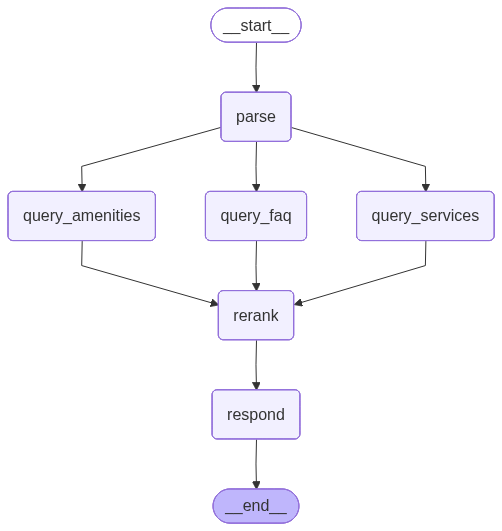

In [130]:
from IPython.display import Image, display  # noqa: A004

display(Image(info_agent.get_graph().draw_mermaid_png()))

Run a couple of tests

In [131]:
prompt = ("Need a 15-minute in-room bite, under $5, no reservation, "
          "can only give 0 hours notice.")
state = info_agent.invoke({"messages": [HumanMessage(content=prompt)]})
state["messages"]

17:17:02 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:17:02 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:17:02 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:17:02 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:17:02 llama_index.vector_stores.redis.base INFO   Querying index amenities with query (((@booking_required:{False} @price:[-inf 5.0]) @min_notice_hours:[-inf 0]) @duration:[-inf 15])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:17:02 llama_index.vector_stores.redis.base INFO   Querying index amenities with query (((@booking_required:{False} @price:[-inf 5.0]) @mi

[HumanMessage(content='Need a 15-minute in-room bite, under $5, no reservation, can only give 0 hours notice.', additional_kwargs={}, response_metadata={}, id='ce145dee-01a7-4b3e-8060-cee5715ee32f'),
 AIMessage(content=[{'id': 'rs_0e7be945bf11ed4a0069bdd582f4cc81a08aee359d51545f29', 'summary': [], 'type': 'reasoning'}, {'type': 'text', 'text': 'I could not find exactly what you requested (a 15-minute in-room option under $5 with no reservation and 0 hours notice), because pricing, timing, and reservation/notice details are not specified. I did find that room service is available 24/7, with a full menu during restaurant hours and a limited menu overnight.', 'annotations': [], 'id': 'msg_0e7be945bf11ed4a0069bdd58681c881a0815da62a66ff5b98'}], additional_kwargs={}, response_metadata={'id': 'resp_0e7be945bf11ed4a0069bdd582a03481a09332dd3798d3d10d', 'created_at': 1774048642.0, 'metadata': {}, 'model': 'gpt-5.2-2025-12-11', 'object': 'response', 'service_tier': 'default', 'status': 'completed

In [132]:
prompt = "I want an hour-long massage."
state = info_agent.invoke({"messages": [HumanMessage(content=prompt)]})
print(state["messages"][1].content[1]["text"])

17:17:27 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:17:27 httpx INFO   HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
17:17:28 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:17:28 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
17:17:28 llama_index.vector_stores.redis.base INFO   Querying index amenities with query (@duration:[60 +inf] @duration:[-inf 60])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id text _node_content vector_distance SORTBY vector_distance ASC DIALECT 2 LIMIT 0 4
17:17:28 llama_index.vector_stores.redis.base INFO   Querying index amenities with query (@duration:[60 +inf] @duration:[-inf 60])=>[KNN 4 @vector $vector AS vector_distance] RETURN 5 id doc_id t